<h1><center>TD1 - Notebook 2 : Comment les caractéristiques d'un bassin versant modifient le réseau hydrographique ? Approche par une modélisation hydrogéologique </center></h1>

### 1. Charger les librairies python

In [1]:
# Libraries installed by default
import sys
import glob
import os
import fnmatch
import random
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".* .*", category=DeprecationWarning)
# Libraries need to be installed if not
import numpy as np
import pandas as pd
import shutil
from geopy.geocoders import Nominatim
# Libraries added from 'conda install' procedure
import geopandas as gpd
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.pylab as pl
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Libraries added from 'conda forge' procedure
from osgeo import gdal, osr # or import gdal
import rasterio
# Libraries installed from the pip procedure
import deepdish as dd
import flopy
import imageio
import vedo
import hydroeval
import xarray	
import netCDF4
import matplotlib_scalebar	
import contextily
import pyproj # uninstall before install
import selenium
import shapefile # named pyshp for install
import jupyter
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\whitebox\whitebox_tools.py:47: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references

### 2. Renseigner les répertoires utilisés et importer les classes Hydromodpy utilisées

#### Répertoire d'Hydromodpy

In [2]:
root_dir = 'C:/Users/camil/Documents/GitHub/HydroModPy'
sys.path.append(root_dir)
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    print("Root path directory is: {0}".format(cwd))

Root path directory is: C:\Users\camil\Documents\GitHub\HydroModPy\teaching


#### Importer les fichiers source Hydromodpy

In [3]:
import src # import the folder src from HydroModpy codes
import importlib # 
importlib.reload(src)
# import all the classes necessary to extract the watershed from Hydromodpy source files.
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

#### Répertoire des données utilisées dans ce TD

In [4]:
teaching_path = root_dir + "/teaching/"
data_path = teaching_path + "/data/"
# complete where modflow sources are
modflow_path = os.path.join(root_dir,'bin/')
#
watershed_name = 'Glueyre'

#### Répertoire des résultats créés dans ce TD

In [5]:
out_path = 'C:/Users/camil/Documents/GitHub/HydroModPy'
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'

### 3. Charger l'objet Bassin Versant déjà créé

In [6]:
print('##### '+watershed_name.upper()+' #####')
load=True
BV = watershed_root.Watershed(dem_path='',
                              out_path=root_dir,
                              load=load,
                              watershed_name=watershed_name,
                              save_object=False)

##### GLUEYRE #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Object was loaded successfully


### 4. Extraire les données de forçage climatique qui seront utilisées pour la modélisation

#### Initialization du module climatique à partir des données de recharge et de runoff disponible dans votre dossier de données

In [7]:
BV.add_climatic()
BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS_mperday.csv',
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')
print(BV.climatic.recharge)

Init climatic module to set model parameter
Datetime
1990-01-01    0.001075
1990-01-02    0.001212
1990-01-03    0.001374
1990-01-04    0.001556
1990-01-05    0.001737
                ...   
2018-07-27    0.000153
2018-07-28    0.000040
2018-07-29    0.000032
2018-07-30    0.000031
2018-07-31    0.000030
Freq: D, Name: REC_REA_historic, Length: 10439, dtype: float64


**Quelle est l'unité de la recharge?**

#### Visualisation des données climatiques

In [8]:
R = BV.climatic.recharge.resample('Y').sum()*1000 
r = BV.climatic.runoff.resample('Y').sum()*1000
#print(R.mean())

**A quoi correspond R ? Quelle est donc la recharge moyenne annuelle?**

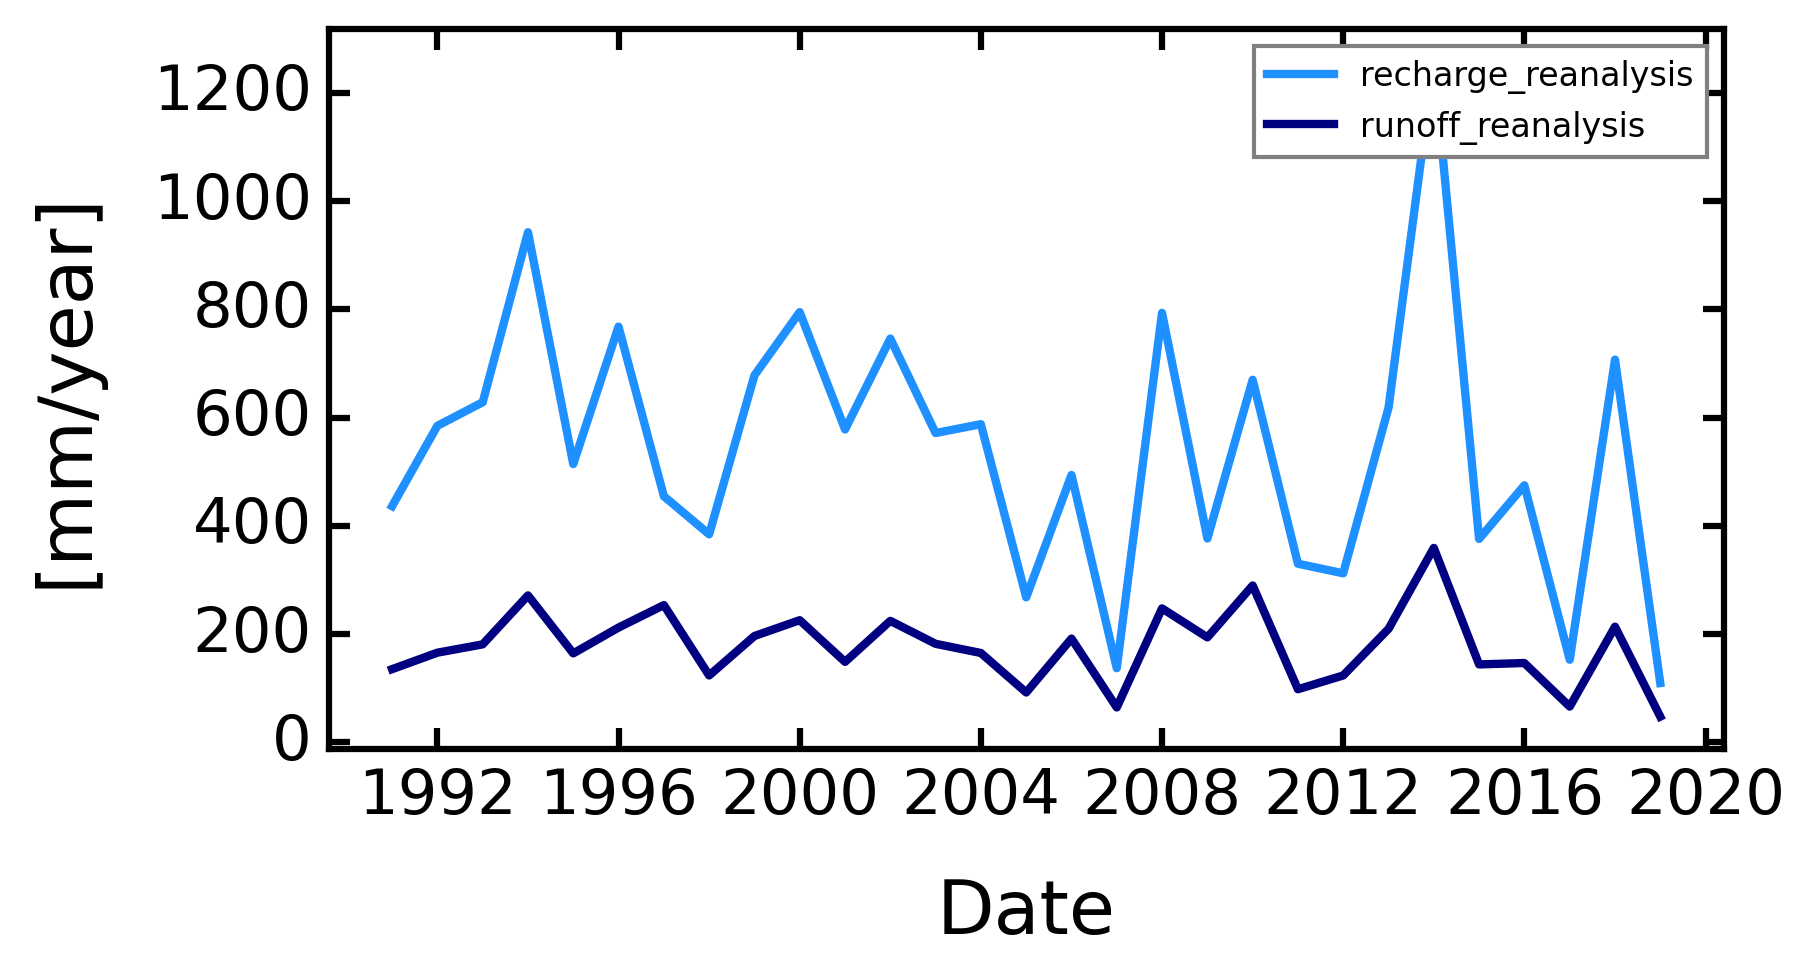

In [9]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/year]')
ax.legend()

**Ces données sont issues d'un modèle climatique + de surface à une échelle de 8x8 grid scale over France.
Qu'est ce que le runoff? Quels sont les deux procédés qui créent du runoff? Qu'est ce que la recharge ?**

### 4. Donner les caractéristiques de l'aquifère modélisé et initialisation du modèle

In [10]:
sim_state = 'steady' # 'steady' or 'transient'

box = True # or False
sink_fill = False # or True
plot_cross = False
first_clim = 'mean'
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 50 # if bottom is None, aquifer thickness
cond_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
verti_cond = None # or [ [1e-5, [0, 20]],
                  #      [1e-6, [20,80]] ]
cond_drain = None # or value of conductance
poro_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

In [11]:
BV.add_settings()
BV.add_geometric()
BV.add_hydraulic()

BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_active_plot(plot_cross=plot_cross)

BV.climatic.update_first_clim(first_clim)

BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None

BV.hydraulic.update_cond_vertical(verti_cond)
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_lay_decay(poro_decay)

BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)

Init settings module to set model parameter
Init hydraulic module to set model parameter


### 4. Exploration de l'effet de la paramétrisation sur le niveau de la nappe et les zones de résurgence

In [12]:
porosity = 10 / 100 # -
hyd_cond = 1e-3 * 24 * 3600 # similar unit as the recharge [m/day]
print(hyd_cond) # valeur utilisée dans le dossier créé de résultats de simulation
#recharge_values = toolbox.select_period(BV.climatic.recharge, 2000, 2000) # in m/day
#BV.climatic.update_recharge(recharge_values[:7], sim_state='transient')
print(BV.climatic.recharge)
recharge_values = BV.climatic.recharge
BV.hydraulic.update_porosity(porosity)
BV.hydraulic.update_hyd_cond(hyd_cond)

86.4
Datetime
1990-01-01    0.001075
1990-01-02    0.001212
1990-01-03    0.001374
1990-01-04    0.001556
1990-01-05    0.001737
                ...   
2018-07-27    0.000153
2018-07-28    0.000040
2018-07-29    0.000032
2018-07-30    0.000031
2018-07-31    0.000030
Freq: D, Name: REC_REA_historic, Length: 10439, dtype: float64


In [13]:
set_simulations = 'parametrization_exploration'
list_model_name = []
list_success_modflow = []
list_model_modflow = []

#### On fait tourner le modèle

In [14]:
model_name = set_simulations+'_k_'+str(round(hyd_cond,3))+'_porosity_'+str(round(porosity,2))+'_rech_'+str(round(recharge_values.mean(),2))
BV.settings.update_model_name(model_name)
print(model_name)

model_modflow = BV.preprocessing_modflow(simulations_folder)
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation = True,
                              watertable_depth= True, 
                              seepage_areas = True,
                              outflow_drain = True,
                              groundwater_flux = True,
                              groundwater_storage = True,
                              accumulation_flux = True,
                              export_all_tif = False)

list_model_name.append(model_name)
list_success_modflow.append(success_modflow)
list_model_modflow.append(model_modflow)

parametrization_exploration_k_86.4_porosity_0.1_rech_0.0
FloPy is using the following executable to run the model: C:\Users\camil\Documents\GitHub\HydroModPy\bin/win\mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: parametrization_exploration_k_86.4_porosity_0.1_rech_0.0.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2023/12/19 11:46:49

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2023/12/19 11:47:48
 Elapsed run time: 58.501 Seconds

  Normal termination of simulation
    Time:  0


#### Résultats du modèle en carte

In [15]:
dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_box_buff_dem.tif') # dem data
stream_data = imageio.imread(stable_folder+'/hydrography/'+'cours_eau_V.tif') # river data
watertable_data = imageio.imread(simulations_folder+model_name+'/_postprocess/_rasters/'+'watertable_elevation_t(0).tif') # watertable data

In [16]:
#visu.interactive_cross_section(dem_data, watertable_data, stream_data, interactive=True)

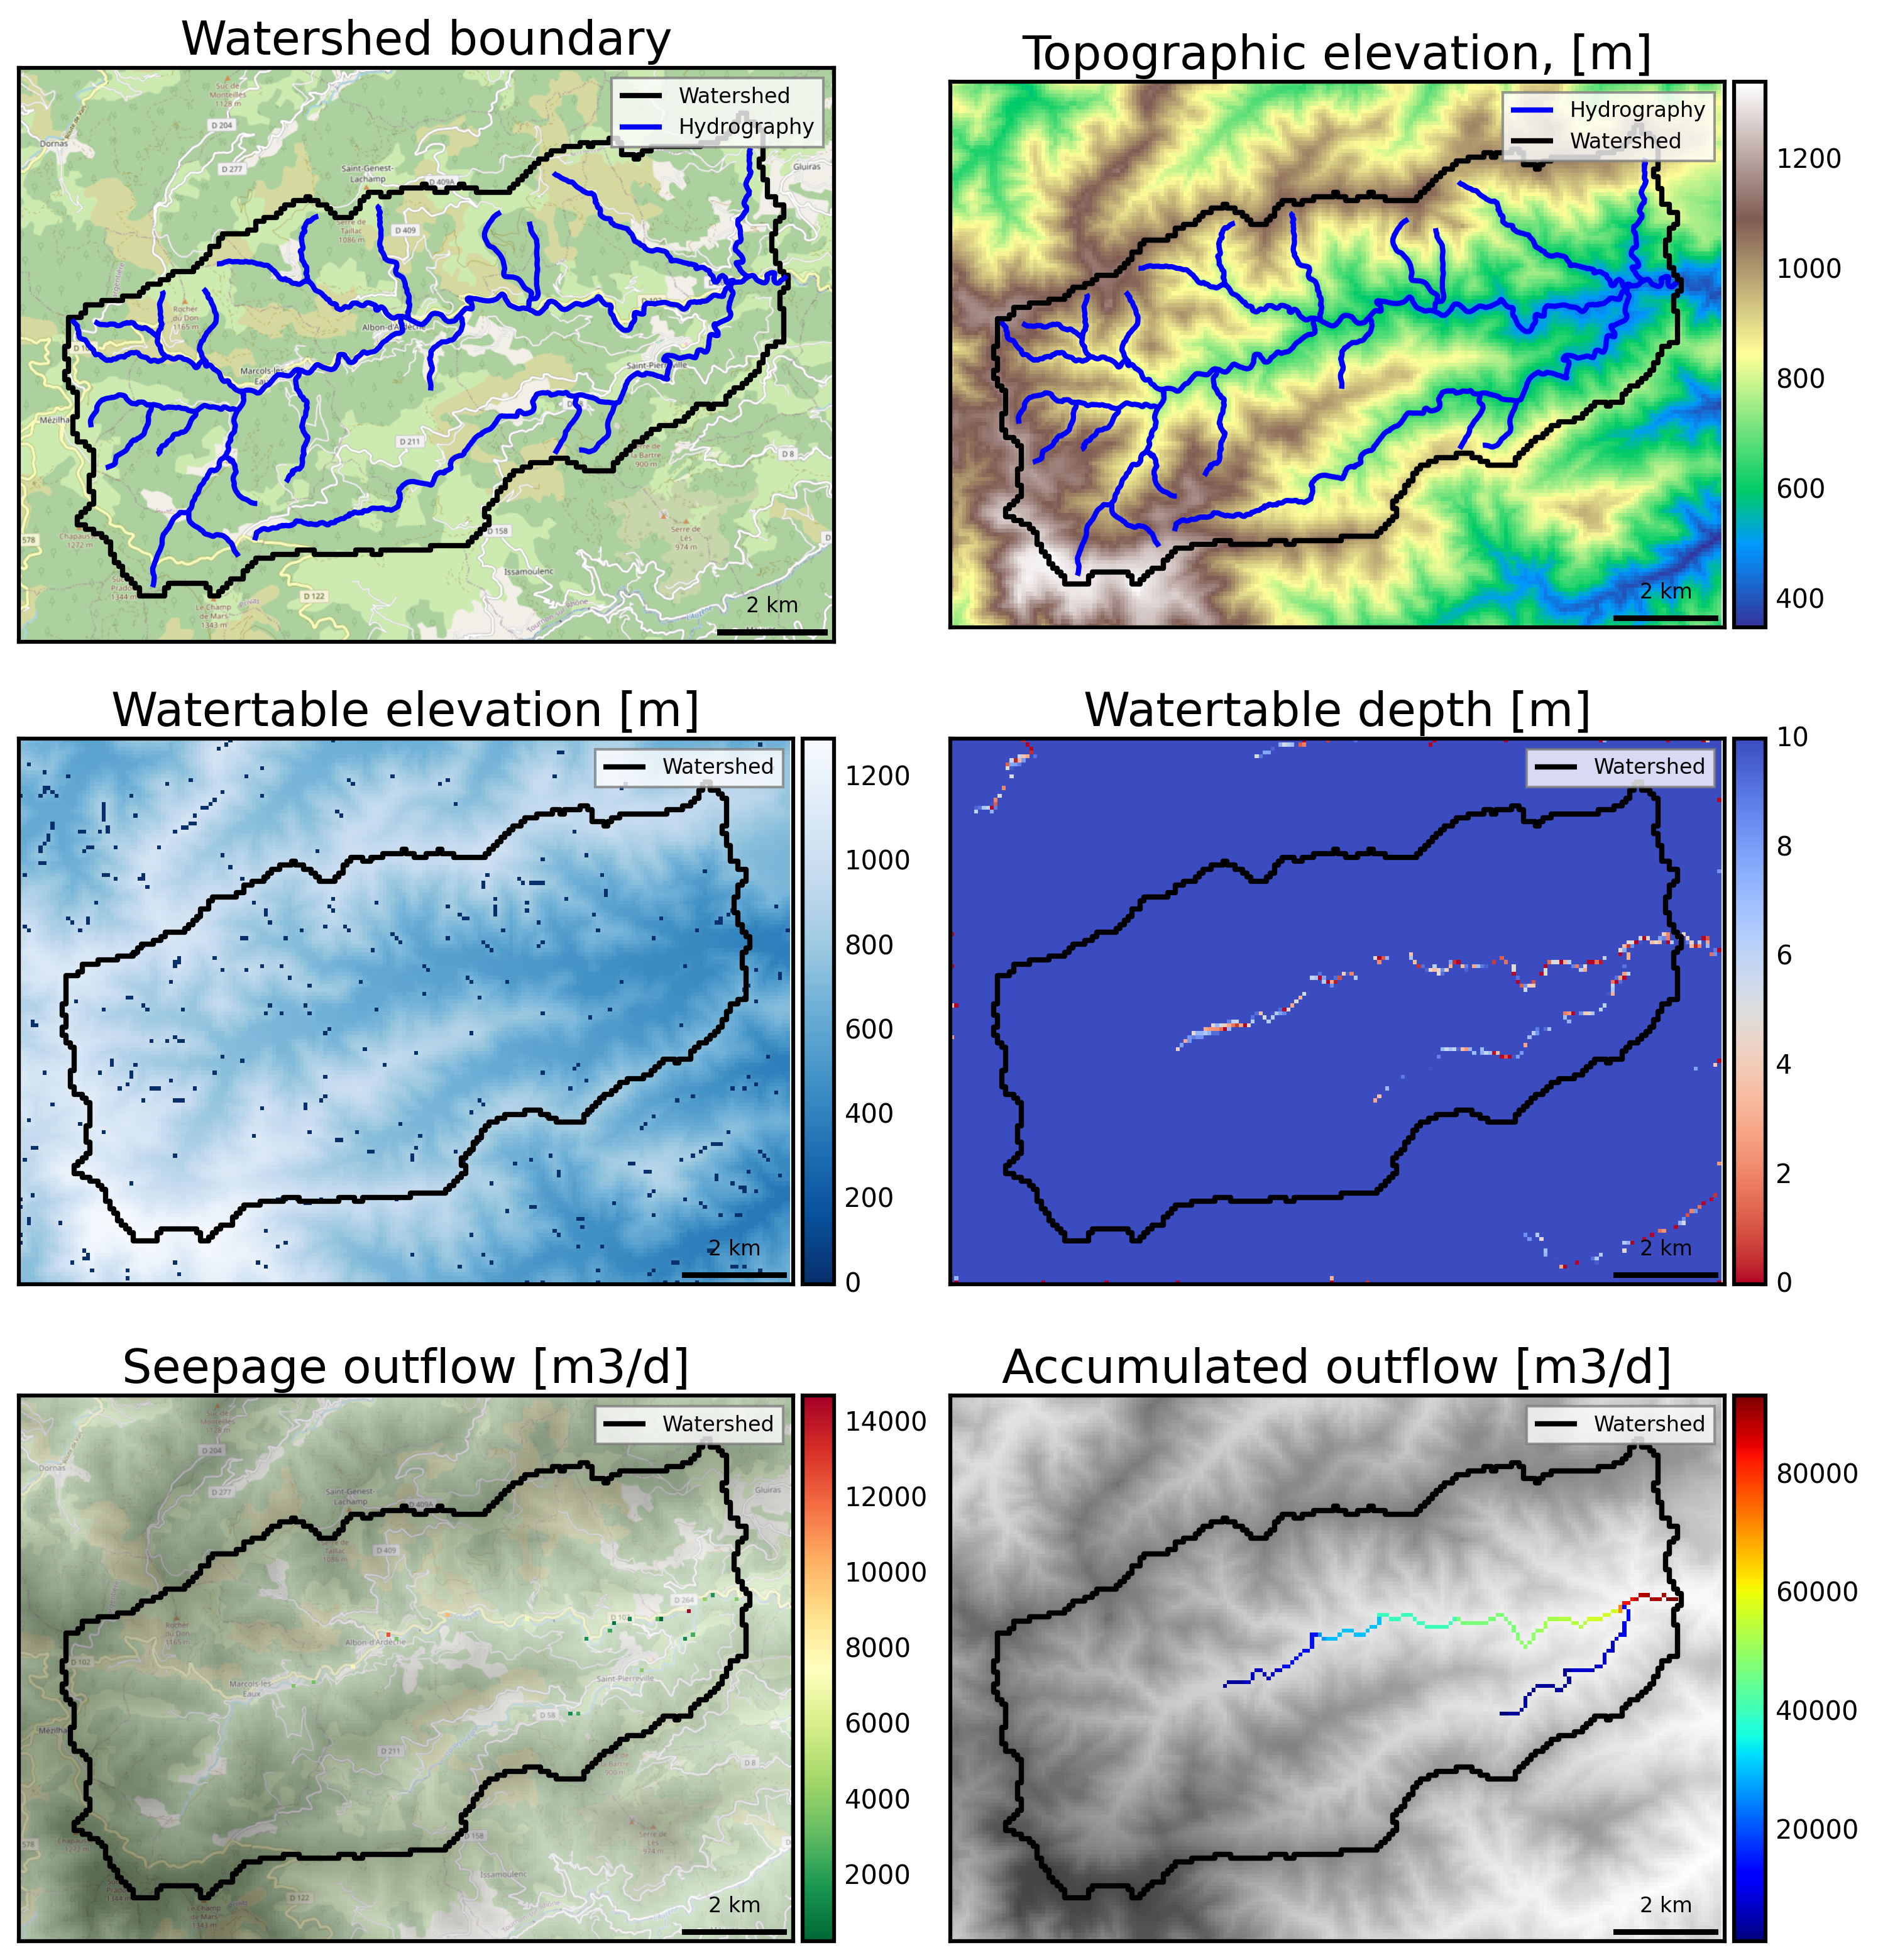

In [17]:
visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = ['map','grid',
                             'watertable', 'watertable_depth',
                             'drain_flow','surface_flow',
                             #'pathlines', 'residence_times'
                             ],
              color_scale = [(None,None),(None,None),
                             (None,None),(0,10),
                             (None,None),(None,None),
                             #(None,None),(None,None),
                             ], 
              lines=100)

**Les résultats de simulation sont tous enregistrés dans le dossier results_simulation. Vous pouvez utiliser les raster générés dans un logiciel de SIG.
En modifiant les valeurs de la recharge, de la perméabilité et de la porosité, explorer leurs effets sur le niveau de la nappe et les zones de résurgence : Quel est l'effet de la recharge? Quel est l'effet de la perméabilité? Quel est l'effet de la porosité? Les résultats obtenus sont-ils cohérents avec ce que nous avons vu en cours?**

**Si l'on considère que les données MétéoFrance sont de bonne qualité, quel paramètre hydraulique l'extension du BV peut permettre de caler? Essayer de calibrer le modèle, c'est à dire de trouver le meilleur paramètre pour simuler les observations, ici l'extension du réseau hydrographoque.** 

#### Résultats quantitatifs moyens du modèle

In [18]:
timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=None,
                                                  actual_date=True, 
                                                  subbasin_results=False)
print(timeseries_results)
timeseries = pd.read_csv(simulations_folder+model_name+'/_postprocess/'+'_timeseries/'+'_simulated_timeseries.csv', sep=';')
print(timeseries)

Extract modflow and modpath results in timeseries
             date  recharge  watertable_elevation  watertable_depth  \
0      1990-01-01  0.001075               791.257           59.2299   
1      1990-01-02  0.001212                   NaN               NaN   
2      1990-01-03  0.001374                   NaN               NaN   
3      1990-01-04  0.001556                   NaN               NaN   
4      1990-01-05  0.001737                   NaN               NaN   
...           ...       ...                   ...               ...   
10434  2018-07-27  0.000153                   NaN               NaN   
10435  2018-07-28  0.000040                   NaN               NaN   
10436  2018-07-29  0.000032                   NaN               NaN   
10437  2018-07-30  0.000031                   NaN               NaN   
10438  2018-07-31  0.000030                   NaN               NaN   

       seepage_areas  outflow_drain  groundwater_flux  groundwater_storage  \
0           0.17542

**Les résultats obtenus vous semblent-ils cohérents?**